<table border=0 width="100%"><tr><td><p align="left"><img src="..\img\logo-1.jpg" align="left" width=300></p></td><td><font size=3><B>sentiment analysis - SVM (Jun Wang)</B></font></td></tr></table>

# Content
* sentiment analysis with lexicon
* sentiment analysis with support vector machine
* ensemble three approaches of sentiment analysis

# sentiment analysis with lexicon

## load the data with cutted_comment

In [7]:
import pandas as pd

In [8]:
import pandas as pd
comments = pd.read_csv("cleaned_300251_comments.csv", ## 数据导入
                      index_col=False,
                      parse_dates = ["modified_date"])

In [9]:
# 使用tail函数查看最后5条评论
comments.tail()

,Unnamed: 0,modified_date,comment,cutted_comment
124329,124223,2019-04-10,当代东方当代东方,当代 东方 当代 东方
124330,124224,2019-04-10,去年盈利那么多。年报分红怎么分。十送三股派五元？去年盈利那么多。年报分红怎么分。十送三股派五元？,去年 盈利 那么 多 。 年报 分红 怎么 分 。 十送 三股 派 五元 ？ 去年 盈利 那...
124331,124225,2019-04-10,刚刚425家公司公布一季度业绩预告5股净利润同比大幅预增!昨日重要公司2019一季度业绩预告...,刚刚 425 家 公司 公布 一季度 业绩 预告 5 股 净利润 同比 大幅 预增 ! 昨日...
124332,124217,2019-04-10,没有希望了！8.68清仓，拿了这么久还是亏钱没有希望了！8.68清仓，拿了这么久还是亏钱,没有 希望 了 ！ 8.68 清仓 ， 拿 了 这么久 还是 亏钱 没有 希望 了 ！ 8....
124333,124333,2019-04-10,特别绝望特别绝望,特别 绝望 特别 绝望


## read the sentiment lexicon in Finance 

我们选择与金融领域更贴近的词典，情感词来源有两个：
* 金融情感词汇[成果](https://www.sciencedirect.com/science/article/pii/S0167923614000232)；
* 为了更贴近股吧评论，我们阅读东方财富股吧评论文本，整理出一部分情感词汇。

这两方面的词汇保存在negative_finance.txt和positive_finance.txt中。这里特别强调一下，这两个文本中的词汇是添加了部分股吧评论情感词汇后的结果。

Python中[open()](https://www.runoob.com/python/file-methods.html)方法用于打开一个文件，并返回文件对象，在对文件进行处理过程都需要使用到这个函数open() 函数常用形式是接收两个参数：文件名(file)和模式(mode)。例如：open(file_path, mode='r')

<table border="1" align = "left">
<tr>
<td>模式</td>
<td>描述</td>
</tr>
<tr>
<td>r</td>
<td>以只读方式打开文件。文件的指针将会放在文件的开头。这是默认模式。</td>
</tr>
<tr>
<td>r+</td>
<td>打开一个文件用于读写。文件指针将会放在文件的开头。</td>
</tr>
<tr>
<td>w</td>
<td>打开一个文件只用于写入。如果该文件已存在则打开文件，并从开头开始编辑，即原有内容会被删除。如果该文件不存在，创建新文件。</td>
</tr>
<tr>
<td>w+</td>
<td>打开一个文件用于读写。如果该文件已存在则打开文件，并从开头开始编辑，即原有内容会被删除。如果该文件不存在，创建新文件。</td>
</tr>
</table>

In [10]:
# 文件保存路径
positive_path = "positive_finance.txt"
negative_path = "negative_finance.txt"

In [11]:
# 以默认方式"r"打开文件
f = open(positive_path,encoding="gbk")
pos = f.read()
f.close()
pos[:100].split()

['红啦',
 '红了',
 '好股',
 '拿住',
 '牛B',
 '稳稳',
 '加油',
 '加仓',
 '暴涨',
 '稳住',
 '冲呀',
 '冲鸭',
 '起飞',
 '安全',
 '放心',
 '安然',
 '安稳',
 '安心',
 '安逸',
 '按期',
 '按时',
 '昂扬',
 '傲然',
 '拔尖',
 '百折不挠',
 '摆脱',
 '板上钉钉',
 '办妥',
 '帮助',
 '褒奖',
 '褒扬',
 '宝贵']

In [12]:
# 读取正面情感词汇
# 使用with语句可以帮助我们自动关闭文件

with open (positive_path,"r",encoding="gbk") as f:
    positive_finance = f.readlines()
    positive_finance = [w.strip() for w in positive_finance]#空格、换行处理 strip

In [13]:
positive_finance[-10:] ## 最后10个词

['助力', '助推', '专利', '专属', '追捧', '走好', '足量', '最优', '做大', '做强']

In [14]:
# 读取负面情感词汇

with open (negative_path,"r",encoding="gbk") as f:
    negative_finance = f.readlines()
    negative_finance = [w.strip() for w in negative_finance]

## count positive and negative words in the comments

In [15]:
import jieba
comment = """我今天简直是巨亏，严重跑输大盘，破发深套其中.经济不发展,没意义,没好处,没回报,不翻红,
还是要看长远点，长治久安不过还是对未来充满了期待和希望。"""
comment = " ".join(jieba.lcut(comment)) # 使用jieba切词
comment

Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/kb/tv69ch3n1936k84ysf8skrph0000gn/T/jieba.cache
Loading model cost 0.459 seconds.
Prefix dict has been built successfully.


'我 今天 简直 是 巨亏 ， 严重 跑 输 大盘 ， 破发 深套 其中 . 经济 不 发展 , 没 意义 , 没 好处 , 没 回报 , 不 翻红 , \n 还是 要 看 长远 点 ， 长治久安 不过 还是 对 未来 充满 了 期待 和 希望 。'

<font color=blue face=雅黑>思考：comment字符串切词后的正面情感词个数有多少？</font>

In [16]:
# 提取正面情感词

pos_words = [w for w in comment.split() if w in positive_finance]

print(pos_words)

len(pos_words)

['经济', '发展', '意义', '好处', '回报', '翻红', '长远', '长治久安', '充满', '期待']


10

In [17]:
import pandas as pd 

# apply 学习 - 增加参数

s = pd.Series([20, 21, 12], index=list("ABC"))
print(s)

# Define a custom function that needs additional positional arguments 

def subtract_custom_value(x, custom_value): ## 参数是一个元组
    return x - custom_value

A    20
B    21
C    12
dtype: int64


In [18]:
# pass additional arguments using the args keyword.
s.apply(subtract_custom_value,args=(10,))

A    10
B    11
C     2
dtype: int64

In [19]:
def count_sentiment_words(comment_text,sentiment):
    """
    基于情感词典，获取评论中对应的正面情感词。
    参数：
        comment_text：切词后的评论文本
        
        sentiment（参数）：是获取正面还是负面情感，1（或大于0）表示提取正面情感个数，0表示提取负面情感个数
    返回：
    
        评论中对应的情感词个数
    """
    comment_words_list = comment_text.split()
    
    if sentiment:
        return len([w for w in comment_words_list if w in positive_finance])
    else:
        return len([w for w in comment_words_list if w in negative_finance])

In [20]:
# 构建一个序列s，并在s上应用函数count_sentiment_words，生成一个新的序列pos_counts

print(comment)

import pandas as pd
s = pd.Series([comment[:100],comment], index=list("AB"))
counts = s.apply(count_sentiment_words,args=(0,))  ### 参数是0 或者 1
counts

我 今天 简直 是 巨亏 ， 严重 跑 输 大盘 ， 破发 深套 其中 . 经济 不 发展 , 没 意义 , 没 好处 , 没 回报 , 不 翻红 , 
 还是 要 看 长远 点 ， 长治久安 不过 还是 对 未来 充满 了 期待 和 希望 。


A    5
B    5
dtype: int64

In [21]:
# 提取股评的正面与负面情感词
comments["cutted_comment"] = comments.cutted_comment.astype("str")
comments["positive_words_count"] = comments.cutted_comment.apply(count_sentiment_words,args = (1,))
comments["negative_words_count"] = comments.cutted_comment.apply(count_sentiment_words,args = (0,))

提醒：上面两行代码运行时间有点长，为了提高效率，可以考虑在count_sentiment_words中使用集合操纵，也就是将评论词汇表与情感词汇表做intersection操作。使用集合的不足是：会把评论中重复的情感词汇漏掉。

## get sentiment score based on lexicon

In [22]:
comments[1000:1005]

,Unnamed: 0,modified_date,comment,cutted_comment,positive_words_count,negative_words_count
1000,1215,2011-08-04,申购到的加昨天的成本为60元？？？狗仙机购？？狗人,申购 到 的 加 昨天 的 成本 为 60 元 ？ ？ ？ 狗仙 机购 ？ ？ 狗人,0,0
1001,1214,2011-08-04,警告所有的散户，千万不要买光线，它是毒品，买它了，你就会破产！警告所有的散户，千万不要买光线...,警告 所有 的 散户 ， 千万 不要 买 光线 ， 它 是 毒品 ， 买 它 了 ， 你 就...,0,4
1002,1213,2011-08-04,"绝密消息:机构操盘手上午有事出去了,下等回来拉升,大家要满仓哦下午猛烈进攻，你抢不到的","绝密 消息 : 机构 操盘手 上午 有事 出去 了 , 下 等 回来 拉升 , 大家 要 满...",1,0
1003,1212,2011-08-04,下午肯定收红盘888,下午 肯定 收 红盘 888,1,0
1004,1211,2011-08-04,【以岭药业】第二！！！！第二天买入【全线套牢】！！！！！！！！！！！！！拭目以待,【 以岭 药业 】 第二 ！ ！ ！ ！ 第二天 买入 【 全线 套牢 】 ！ ！ ！ ！ ...,1,1


该算法是基于积极与消极情感词频计数，是最简单和最直观的分类器 ** (Das & Chen, 2007) **。

* 评论中的每个单词都根据字典进行检查，对正面词和负面词的权重是+1和- 1。我们已计算正面词和负面词个数，只需要：$$1*正面词个数+(-1*负面词个数)$$
* 所有情感词带权相加，如果结果大于0，评论的情感是1（正向），否则为-1（负向）

python 使用 lambda 来创建匿名函数:lambda argument_list: expression。
我们可以将lambda函数作为参数传递给其他函数

In [23]:
a = map(lambda x: 1 if x>0 else -1,[-1,1,-3,4,-5])
list(a)

[-1, 1, -1, 1, -1]

In [24]:
# 正面词-负面词，即累积情感分数
sentiment_total_score = comments.positive_words_count - comments.negative_words_count
# 如果累积情感分数大于零，返回1，否则返回-1，即：看涨（1）、看跌（-1）
sentiment_dict = sentiment_total_score.apply(lambda x: 1 if x>0 else -1)
# 将情感序列复制给sentiment_dict_based列
comments["sentiment_dict_based"] = sentiment_dict

In [25]:
comments[1000:1005]

,Unnamed: 0,modified_date,comment,cutted_comment,positive_words_count,negative_words_count,sentiment_dict_based
1000,1215,2011-08-04,申购到的加昨天的成本为60元？？？狗仙机购？？狗人,申购 到 的 加 昨天 的 成本 为 60 元 ？ ？ ？ 狗仙 机购 ？ ？ 狗人,0,0,-1
1001,1214,2011-08-04,警告所有的散户，千万不要买光线，它是毒品，买它了，你就会破产！警告所有的散户，千万不要买光线...,警告 所有 的 散户 ， 千万 不要 买 光线 ， 它 是 毒品 ， 买 它 了 ， 你 就...,0,4,-1
1002,1213,2011-08-04,"绝密消息:机构操盘手上午有事出去了,下等回来拉升,大家要满仓哦下午猛烈进攻，你抢不到的","绝密 消息 : 机构 操盘手 上午 有事 出去 了 , 下 等 回来 拉升 , 大家 要 满...",1,0,1
1003,1212,2011-08-04,下午肯定收红盘888,下午 肯定 收 红盘 888,1,0,1
1004,1211,2011-08-04,【以岭药业】第二！！！！第二天买入【全线套牢】！！！！！！！！！！！！！拭目以待,【 以岭 药业 】 第二 ！ ！ ！ ！ 第二天 买入 【 全线 套牢 】 ！ ！ ！ ！ ...,1,1,-1


In [26]:
comments.sentiment_dict_based.value_counts() # 查看正面评论与负面评论的个数

-1    80423
 1    43911
Name: sentiment_dict_based, dtype: int64

In [27]:
# 保存数据
comments.to_csv("cleaned_300251_comments_sentiment.csv",encoding = "gbk" ) # 保存情感分析结果数据

# introduction to support vector machine

由于我们要使用SGDClassifier做分类器，而该模型可以实现**线性支持向量机（linear support vector machine）**。因此这里我们要首先讲一下支持向量机。支持向量机的原理内容较多，我们这里仅仅介绍到基于**合页损失函数（hinge loss function）** 视角来求解线性支持向量机的**最优超平面**。主要参考资料是李航（2012）第7章支持向量机的内容。

参考资料：李航，统计学习方法，2012，北京.清华大学出版社.

## Linearly separable support vector machines

假设在一个特征空间上的训练数据集$T = \{(x_1,y_1),(x_2,y_2),...,(x_N,y_N)\}$,其中$y_i\in\{+1,-1\},i = 1,2,...,N$,当$y_i = +1$时，$x_i$称为正例，当$y_i = -1$时，$x_i$称为负例。学习的目标是在特征空间中找到一个超平面，将样本分到不同的类。**（可以是不同的维度，SVM-1）**

**分离超平面对应于$w.x + b = 0$**,该平面由法向量$w$和截距$b$决定，可以用$(w,b)$来表示。

对于线性可分问题，有多个平面（超平面）（这里是线来表示）可以将样本分开。由于存在多个平面，我们**基于间隔最大化（最近的样本，离超平面的距离最大，SVM-0）**求出分离超平面$(w^*,b^*)$，相应的分类决策函数是$f(x) = sign(w^*.x+b^*)$,其中
$sign = \begin{cases}
+1,& w^*.x+b^*>=0 \\ -1,& w^*.x+b^*<0 
\end{cases}$

<img src="../img/svm.png"  height="200" width="300"/>

如何定义点到超平面的间隔呢，这里引入**函数间隔与几何间隔**。

**我们自己定义一个公式$|w*x+b|$，表示点x距离超平面的距离**。标记$y$与$w*x+b$的符号是否一致能够表示分类是否正确：
$$w*x+b>0时，y=1$$
$$w*x+b<0时，y=-1$$

因此$y$与$w*x+b$永远同号，所以$y(w*x+b)$在预测分离超平面上恒大于$0$。所以**函数间隔$y(w*x+b)$**能够度量分类的正确性以及可信度。

函数间隔的正式定义如下：
对于给定的训练集T和超平面$(w,b)$,定义超平面关于样本点的函数间隔（超平面层面而言）为$$\hat\gamma_i = y_i(w.x_i+b)$$
超平面关于数据集T的函数间隔为T中**所有样本点的函数间隔的最小值（数据层面而言）**，即：$$\hat \gamma = \underset{i=1,...,N}{min}{\hat\gamma_i}$$

函数间隔有个特点**（或者叫不足）**，就是能够**等比例的缩放，而超平面并没有改变**。例如，$4x_1 + 6x_2 + 8 = 0$和$2x_1 + 3x_2 + 4 = 0$描述的其实是同一个平面，但是函数距离却被缩成了原来的$1/2$。

**这里给我们一些启示，我们可以对超平面的$w$规范化，例如 $||w||=1$。这时函数间隔变为几何间隔**。

什么是几何间隔：如下图所示，点$x_i$与超平面$(w,b)$的距离是**（点到直线的距离公式）**$$\gamma_i = y_i(\frac {w}{||w||}.x_i + \frac {b}{||w||})$$

超平面关于训练集T的几何间隔定义如下$$\gamma = \underset {i=1,...,N}{min}\gamma_i$$

<img src="../img/jihe_gap.png"  height="200" width="300"/>

几何间隔最大化的直观解释是：（超平面层面而言）对训练数据集**找到几何间隔最大的超平面**意味着**以充分大的确信度对训练数据进行分类**。下面考虑求一个几何间隔最大的分离超平面，具体而言，这个问题可以表示为下面的约束最优化问题： **下面最优化的意义是什么？（1）最小的样本是距离的最大化 （2）其他样本肯定要比这个最小的样本距离大**

$
\underset{w,b}{max}\:\gamma\\
s.t. y_i(\frac{w}{||w||}.x_i + \frac {b}{||w||}) \geq \gamma, i = 1,2,...,N
$

从函数间隔和几何间隔的定义可知，二者的关系如下：**（替换的操作）**
$$\gamma_i = \frac{\hat \gamma_i}{||w||}$$
$$\gamma = \frac{\hat \gamma}{||w||}$$
考虑到集合间隔和函数间隔的关系式$\gamma = \frac{\hat \gamma}{||w||}$，可以将上述几何间隔最大化问题改写为：

$
\underset{w,b}{max}\:\frac{\hat \gamma}{||w||}\\
s.t. y_i(w.x_i + b) \geq \hat \gamma, u = 1,2,...,N
$

针对最优化问题：
$
\underset{w,b}{max}\:\frac{\hat \gamma}{||w||}\\
s.t. y_i(w.x_i + b) \geq \hat \gamma, u = 1,2,...,N
$

因为函数间隔$\hat \gamma$的取值并不影响最优化问题的解。例如，我们将w和b按比例改变为$\lambda w$和$\lambda b$,这时函数间隔成为$\lambda \hat \gamma$。**函数间隔的这一改变对上面最优化问题的不等式约束没有影响**，即$y_i(\lambda w.x_i + \lambda b) \geq \lambda \hat \gamma$.这样我们就可以取$\hat \gamma = 1$,而且最大化问题可以通过取倒数变为最小化问题，**（经过一系列变化：w 和 b 等比例变化，最大化变成最小化）**如下所示：

$
\underset{w,b}{min}\:\frac{1}{2}||w||^2\\
s.t. y_i(w.x_i + b) -1\geq 0, i = 1,2,...,N
$

<font color=red face=雅黑>思考：为什么线性可分支持向量机优化函数的约束中，函数间隔要大于等于1，大于等于2可以吗？

$
\underset{w,b}{min}\:\frac{1}{2}||w||^2\\
s.t. y_i(w.x_i + b) \geq 1, i = 1,2,...,N
$</font>


例子：$正样本点x_1 = (3,3)^T, x_2 = (4,3)^T, 负样本点x_3 = (1,1)^T$。

$
\underset{w,b}{min}\:\frac{1}{2}||w||^2\\
s.t. y_i(w.x_i + b) \geq 1, i = 1,2,...,N
$</font>

通过Convex Optimization（凸规划）求解可以得到w和b。可以使用lingo或者python的工具[CVXOPT](http://cvxopt.org/index.html)
具体步骤可以参考[Cvxopt  python 凸优化包应用](https://blog.csdn.net/goodxin_ie/article/details/84591530)

**除了尝试直接求解（非线性问题，特征比较多的情况），也可以求解上述最优化问题的对偶问题。参考[支持向量机SVM（Support Vector Machine）]**(https://www.bilibili.com/video/BV1Hs411w7ci?from=search&seid=12279045291850444775)

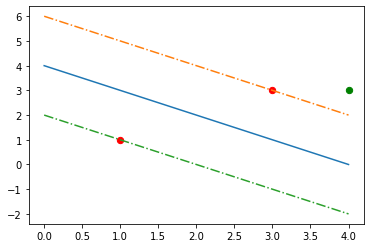

In [55]:
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(0,5)
y = 4 - x
plt.plot(x,y)
plt.scatter(3, 3, marker = 'o',color = 'red', s = 40 ,label = 'positive')
plt.scatter(4, 3, marker = 'o',color = 'green', s = 40 ,label = 'positive')
plt.scatter(1, 1, marker = 'o',color = 'red', s = 40 ,label = 'positive')
y2 = y+2
y3 = y-2
plt.plot(x,y2,"-.")
plt.plot(x,y3,"-.")

在线性可分的情况下，训练数据集的样本点中与分离超平面距离最近的点的实例被称为支持向量（support vector）。对正例点，支持向量在超平面$H_1: w.x + b = 1$上，而对于负例点，支持向量在超平面$H_1: w.x + b = -1$上。H1与H2之间的距离称为间隔，间隔依赖于超平面的法向量$w$，等于$\frac {2}{||w||}$。在决定分离超平面时，只有支持向量起作用。

<img src="../img/support_vector.png"  height="300" width="400"/>

## Linear support vector machines with soft margin optimization

### 线性不可分

线性可分问题的支持向量机对于线性不可分的数据是不适用的。如下图所示：

<img src="../img/svm_linear.png"  height="100" width="200"/>

**线性不可分意味着某些点，不能满足函数间隔大于等于1的约束条件。（等于1意味着在边界上）（距离更小了）**

**（目标惩罚项，约束松弛项）**为了解决这个问题，可以对每个样本点$(x_i,y_i)$**引入一个（柔性的）松弛变量**$\varepsilon_i \geq 0$,使得函数间隔加上松弛变量大于等于1，**这样约束条件变为：**$y_i(w.x_i + b) \geq 1 - \varepsilon_i $,同时，对每个松弛变量$\varepsilon_i$支付一个代价（**错误分类需要增加代价**）$\varepsilon_i$，这样目标函数由原来的$\frac{1}{2}||w||^2$变为$\frac{1}{2}||w||^2 + C \sum_{i=1}^N \varepsilon_i$. 这里$C>0$称为惩罚参数，C越大表示对误分类的惩罚增大。最小化该目标函数的含义有两层：一是$\frac{1}{2}||w||^2$最小，即最大化间隔，第二层含义是使误分类点的个数尽肯能小。这样，对于线性不可分的问题，我们就可以采用这样的软间隔最大化来求解最优的超平面$(w,b)$。我们要优化的问题变成下面的形式：

$
\underset{w,b}{min}\:\frac{1}{2}||w||^2 + C \sum_{i=1}^N \varepsilon_i\\
s.t. \\
y_i(w.x_i + b) \geq 1 - \varepsilon_i, i = 1,2,...,N\\
\varepsilon_i \geq 0, i = 1,2,...,N
$

## Hinge loss function

### 针对错误分类的点，引入合页损失函数

线性支持向量机的学习还有另外一种解释，就是最小化以下目标函数：$$\sum_{i=1}^N {[1-y_i(w.x_i+b)]_+} + \lambda ||w||^2$$

目标函数的第一项就是经验损失函数，$L(y_i(w.x_i+b)) = [1-y_i(w.x_i+b)]_+$

该函数称为合页损失函数（hinge loss function）。下标“+”表示一下取正值的函数
$[z]_+ = \begin{cases}
z,&z>0 \\ 0,&x\le0 
\end{cases}$

该损失函数表示当样本点被正确分类**函数间隔（确信度）$y_i(w.x_i+b)$大于1时，损失是0**.**否则，损失是$1-y_i(w.x_i+b)$**.
目标函数的第二项是系数为$\lambda$的$w$的$L2$范数（**防止超平面过拟合的问题**），即各个系数的平方和。

下面我们用一个图示来看合页损失函数。**分类错误-惩罚；分类正确-不惩罚**  
**下标“+”表示一下取正值的函数**
$[1- y_i(w.x_i+b)]_+ = \begin{cases}
1- y_i(w.x_i+b),&y_i(w.x_i+b)<1 （非正确分类）\\ 0,&y_i(w.x_i+b)\ge1 （正确分类）
\end{cases}$

<img src="../img/hinge.png"  height="300" width="400"/>
<img src="../img/hinge_tool.jpg"  height="100" width="200"/>

下面解释线性支持向量机最优化问题（原始最优化问题）：
$
\underset{w,b}{min}\:\frac{1}{2}||w||^2 + C \sum_{i=1}^N \varepsilon_i\\
s.t. \\
y_i(w.x_i + b) \geq 1 - \varepsilon_i, i = 1,2,...,N\\
\varepsilon_i \geq 0, i = 1,2,...,N
$

**等价于最优化问题**：$$\underset {w,b} {min}\sum_{i=1}^N {[1-y_i(w.x_i+b)]_+} + \lambda ||w||^2$$

证明：

令$[1-y_i(w.x_i+b)]_+ = \varepsilon_i$,则$\varepsilon_i \geq 0$，<mark>这满足原始最优化问题的第二项约束条件<mark>。

由$[1-y_i(w.x_i+b)]_+ = \varepsilon_i$可知：

**当$1-y_i(w.x_i+b)> 0$时**，有$[1-y_i(w.x_i+b)]_+ =1-y_i(w.x_i+b) = \varepsilon_i $，因此$y_i(w.x_i+b) = 1- \varepsilon_i $；

**当$1-y_i(w.x_i+b)\le 0$时**，有$[1-y_i(w.x_i+b)]_+ =0 = \varepsilon_i $，即$\varepsilon_i=0 $，此时$y_i(w.x_i+b)\geq 1-\varepsilon_i$

综合上述两种情况（$1-y_i(w.x_i+b)> 0$和$1-y_i(w.x_i+b)\le 0$），都有$y_i(w.x_i+b)\geq 1-\varepsilon_i$，<mark>这满足原始最优化问题的第一个约束条件<mark>。

从上面证明带有**合页损失函数**的最优化问题$$\underset {w,b} {min}\sum_{i=1}^N {[1-y_i(w.x_i+b)]_+} + \lambda ||w||^2$$已经满足原始问题的两个约束调价。

**由于我们令**$[1-y_i(w.x_i+b)]_+ = \varepsilon_i$，此时我们把$\underset {w,b} {min}\sum_{i=1}^N {[1-y_i(w.x_i+b)]_+} + \lambda ||w||^2$改写如下：$$\underset {w,b} {min}\sum_{i=1}^N {\varepsilon_i} + \lambda ||w||^2$$

**若取**$\lambda  = \frac {1}{2C}$,则上述最优化函数进一步改写为（**括号里面的就是原始问题的目标函数**）：$$\underset {w,b} {min}\frac{1}{C}(\frac{1}{2}||w||^2 + C\sum_{i=1}^N{\varepsilon_i})$$

$$\underset {w,b} {min}\frac{1}{C}(\frac{1}{2}||w||^2 + C\sum_{i=1}^N{\varepsilon_i})$$

**从括号内函数看，该目标函数已经等价于原始最优化的目标函数:**$\underset{w,b}{min}\:\frac{1}{2}||w||^2 + C \sum_{i=1}^N \varepsilon_i$

到这里，我们已经证明了求解最优化问题：$$\underset {w,b} {min}\sum_{i=1}^N {[1-y_i(w.x_i+b)]_+} + \lambda ||w||^2$$就可以得到线性支持向量机的超平面$(w,b)$

**（在没有约束的前提下，可以使用梯度下降）**要求线性支持向量机的超平面，就是要找到使带有合页损失函数的经验损失最小的参数$w$和$b$，假设我们要求得参数是$\theta$，在线性支持向量机中，$\theta$就是$w$和$b$。梯度下降的一般原理可以用下图展示。即从一个初始的参数，沿着函数下降的方向逐步更新参数。

<img src="../img/sgd.png"  height="300" width="400"/>

# sentiment analysis with SVM

**准备数据**

我们之前在朴素贝叶斯模型做情感分析时，已经学习了这块数据准备的内容，这里我们运行一下就可以。
* 准备训练数据
* 准备中文停用词

In [56]:
import pandas as pd
labeled_comments = pd.read_csv("labeled_reviews.csv",
                                index_col=False,
                                usecols= ["comment","sentiment_label"],encoding = "gbk")
# 去掉labeled_comments中含有"光线传媒:"的评论
drop_index = labeled_comments[labeled_comments.comment.str.contains("光线传媒:")].index
labeled_comments.drop(drop_index,inplace=True,axis=0)
# 去掉labeled_comments中评论字数超过1000的评论评论
drop_index = labeled_comments[labeled_comments.comment.str.len()>1000].index
labeled_comments.drop(drop_index,inplace=True,axis=0)

In [57]:
import jieba
jieba.load_userdict("userdict.txt")

def cut_comment(comment_text):
    """
    对一个段文本切词，并返回空格拼接后的字符串
    参数：
        comment_text：要被切词的股评文本
    返回：
        使用空格拼接后的字符串
    """
    r = jieba.lcut(comment_text)
    joined_text = " ".join(r)
    return joined_text

labeled_comments["cutted_comment"] = labeled_comments.comment.apply(cut_comment)

In [58]:
from sklearn.model_selection import train_test_split
###训练集与测试集划分
X_train, X_test, y_train, y_test = train_test_split(labeled_comments.cutted_comment,
                                                    labeled_comments.sentiment_label,
                                                    test_size = 0.1,
                                                    random_state = 42)

In [59]:
def detect_encoding(file):
    #获取文件最可能的编码格式
    import chardet
    with open(file, "rb") as f:
        r = f.read()
    e = chardet.detect(r)
    encoding = e.get("encoding")
    return encoding

In [60]:
def get_Chinese_stopwords(stop_words_file):
    """
    读取中文停用词
    参数：
        中文停用词文件
    返回：
        中文停用词列表
    """
    encoding = detect_encoding(stop_words_file)
    with open(stop_words_file,encoding = encoding) as f:
        stopwords = f.read()
    stopwords_list = stopwords.split('\n')
    custom_stopwords_list = [i for i in stopwords_list]
    return custom_stopwords_list

stop_words = get_Chinese_stopwords("stopwordsHIT.txt")

[SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn-linear-model-sgdclassifier)主要**应用在大规模稀疏数据问题上**，经常用在文本分类及自然语言处理。假如数据是稀疏的，该模块的分类器可轻松解决如下问题：超过10^5的训练样本、超过10^5的features（**特征非常多的情况下，例如词袋法**）。

In [34]:
from sklearn.linear_model import SGDClassifier

带有**合页损失函数**的SVM最优化问题$$\underset {w,b} {min}\sum_{i=1}^N {[1-y_i(w.x_i+b)]_+} + \lambda ||w||^2$$

In [35]:
# loss: The loss function to be used. Defaults to ‘hinge’, which gives a linear SVM.
# penalty: Defaults to ‘l2’ which is the standard regularizer for linear SVM models.
# random_state：The seed of the pseudo random number generator to use when shuffling the data.
# max_iter：The maximum number of passes over the training data (i.e. epochs) 
sgd_clf = SGDClassifier(loss = "hinge",
                        penalty = "L2",
                        random_state=42,
                        max_iter=50)## epoch的次数

In [36]:
from sklearn.feature_extraction.text import CountVectorizer ##构造词袋
counter = CountVectorizer(token_pattern ='\w+')

TF-IDF（Term Frequency-Inverse Document Frequency）是一种常用于信息处理和数据挖掘的加权技术。该技术采用一种统计方法，根据字词的在文本中出现的次数和在整个语料中出现的文档频率来计算一个字词在整个语料中的重要程度。它的优点是能过滤掉一些常见的却无关紧要本的词语，同时保留影响整个文本的重要字词。计算公式如下：$$tf-idf_{i,j} = tf_{i,j}*idf_{i}$$

$tf_{i,j}$表示单词i在文档j中出现的次数，这里重点介绍一下$idf_{i}$。$idf_{i}$称为逆文档频率，它是文档频率的倒数，主要用于降低所有文档中一些常见却对文档影响不大的词语的作用。
$$idf_{i} = log(\frac {D}{1+D_{i}})$$

其中，$D$表示文档总数，$D_i$表示包含词汇$i$的文档的总数。从这个表达式可以看出，如果包含词汇$i$的文档增加，那么该词汇的重要性在降低。

In [37]:
from sklearn.feature_extraction.text import TfidfTransformer ## TF-IDF
tf_idf = TfidfTransformer()

In [38]:
from sklearn.pipeline import Pipeline ### 组成管道
#sgd_pipe = make_pipeline(counter,tf_idf,sgd_clf)
sgd_pipe = Pipeline([('count', counter), ("tf_idf",tf_idf),('clf', sgd_clf)])
sgd_pipe.set_params(count__stop_words=stop_words,count__ngram_range=(1,2))
# 输入数据X_train.tokenized_comment, y_train训练模型
sgd_pipe.fit(X_train, y_train)

Pipeline(steps=[('count',
                 CountVectorizer(ngram_range=(1, 2),
                                 stop_words=['exp', 'lex', 'β', 'δ', 'λ', 'ξ',
                                             'ψ', 'в', 'ⅲ', '①①', '①②', '①③',
                                             '①④', '①⑤', '①⑥', '①⑦', '①⑧', '①⑨',
                                             '①ａ', '①ｂ', '①ｃ', '①ｄ', '①ｅ', '①ｆ',
                                             '①ｇ', '①ｈ', '①ｉ', '①ｏ', '②①', '②②', ...],
                                 token_pattern='\\w+')),
                ('tf_idf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(max_iter=50, penalty='L2', random_state=42))])

In [61]:
#使用测试数据做预测
from sklearn.metrics import accuracy_score
y_pred = sgd_pipe.predict(X_test)
# 画出confusion_matrix
accuracy_score(y_test, y_pred)

0.8848920863309353

保存模型

In [40]:
import joblib
joblib.dump(sgd_pipe, "sgd_model.m")

['sgd_model.m']

# ensemble three approaches of sentiment analysis

截至目前，我们已经学习了三类情感分析模型，分布是基于词典的分类器、朴素贝叶斯模型分类器、SGD分类器实现的线性支持向量机。这节课我们把三种分类器组合起来，**类似三个专家，采用投票的方式对股评做情感分析**。

Sanjiv R. Das, Mike Y. Chen, (2007) Yahoo! for Amazon: Sentiment Extraction from Small Talk on the Web. Management
Science 53(9):1375-1388.

In [41]:
comments = pd.read_csv("cleaned_300251_comments_sentiment.csv",encoding = "gbk" ) # 保存情感分析结果数据
comments.head()

,Unnamed: 0,Unnamed: 0.1,modified_date,comment,cutted_comment,positive_words_count,negative_words_count,sentiment_dict_based
0,0,0,2011-07-15,"高泡沬发行新股,破坏了上市公司融资,另打新的热闹气氛散去近期打新虽然有一些利润,但打新股民没...","高泡 沬 发行 新股 , 破坏 了 上市公司 融资 , 另 打 新 的 热闹 气氛 散 去 ...",4,4,-1
1,1,1,2011-07-15,中吧中新股发大财,中 吧 中 新股 发大财,0,0,-1
2,2,2,2011-07-15,33,33,0,0,-1
3,3,3,2011-07-15,发行价30块立帖为证,发行价 30 块 立帖 为证,0,0,-1
4,4,4,2011-07-15,发行价26元市盈率24倍,发行价 26 元 市盈率 24 倍,0,0,-1


In [42]:
comments["cutted_comment"] = comments["cutted_comment"].astype(str) ### 类型转换，确保是字符串类型

## load MultinomialNB model and use it to predict sentiment

In [43]:
# 导出MultinomialNB模型
import joblib

In [44]:
MultinomialNB_model = joblib.load("MultinomialNB_model.m")

/Users/cosmic/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:310: UserWarning: Trying to unpickle estimator CountVectorizer from version 0.23.2 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/Users/cosmic/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:310: UserWarning: Trying to unpickle estimator MultinomialNB from version 0.23.2 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/Users/cosmic/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:310: UserWarning: Trying to unpickle estimator Pipeline from version 0.23.2 when using version 0.24.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(


In [45]:
# 使用已经训练好的MultinomialNB模型对股评进行情感打分
pred = MultinomialNB_model.predict(comments.cutted_comment)  ## 针对cutted_comment,输入到模型里面，即可得到预测值；因为训练好的模型里面包含着管道
comments["sentiment_MultinomialNB_clf"] = pred

In [46]:
comments.tail()

,Unnamed: 0,Unnamed: 0.1,modified_date,comment,cutted_comment,positive_words_count,negative_words_count,sentiment_dict_based,sentiment_MultinomialNB_clf
124329,124329,124223,2019-04-10,当代东方当代东方,当代 东方 当代 东方,0,0,-1,1
124330,124330,124224,2019-04-10,去年盈利那么多。年报分红怎么分。十送三股派五元？去年盈利那么多。年报分红怎么分。十送三股派五元？,去年 盈利 那么 多 。 年报 分红 怎么 分 。 十送 三股 派 五元 ？ 去年 盈利 那...,4,0,1,-1
124331,124331,124225,2019-04-10,刚刚425家公司公布一季度业绩预告5股净利润同比大幅预增!昨日重要公司2019一季度业绩预告...,刚刚 425 家 公司 公布 一季度 业绩 预告 5 股 净利润 同比 大幅 预增 ! 昨日...,5,0,1,1
124332,124332,124217,2019-04-10,没有希望了！8.68清仓，拿了这么久还是亏钱没有希望了！8.68清仓，拿了这么久还是亏钱,没有 希望 了 ！ 8.68 清仓 ， 拿 了 这么久 还是 亏钱 没有 希望 了 ！ 8....,0,4,-1,-1
124333,124333,124333,2019-04-10,特别绝望特别绝望,特别 绝望 特别 绝望,0,2,-1,-1


## load SGD model and use it to predict sentiment

In [47]:
# 导出sgd模型
sgd_model_loaded = joblib.load("sgd_model.m")

In [48]:
# 使用已经训练好的sgd分类器对研究数据进行情感打分
pred = sgd_model_loaded.predict(comments.cutted_comment)
comments["sentiment_sgd_clf"] = pred

In [49]:
comments.head()

,Unnamed: 0,Unnamed: 0.1,modified_date,comment,cutted_comment,positive_words_count,negative_words_count,sentiment_dict_based,sentiment_MultinomialNB_clf,sentiment_sgd_clf
0,0,0,2011-07-15,"高泡沬发行新股,破坏了上市公司融资,另打新的热闹气氛散去近期打新虽然有一些利润,但打新股民没...","高泡 沬 发行 新股 , 破坏 了 上市公司 融资 , 另 打 新 的 热闹 气氛 散 去 ...",4,4,-1,-1,-1
1,1,1,2011-07-15,中吧中新股发大财,中 吧 中 新股 发大财,0,0,-1,-1,-1
2,2,2,2011-07-15,33,33,0,0,-1,-1,-1
3,3,3,2011-07-15,发行价30块立帖为证,发行价 30 块 立帖 为证,0,0,-1,-1,-1
4,4,4,2011-07-15,发行价26元市盈率24倍,发行价 26 元 市盈率 24 倍,0,0,-1,-1,-1


## ensemble sentiment analysis results from three approaches

In [50]:
comments.tail()

,Unnamed: 0,Unnamed: 0.1,modified_date,comment,cutted_comment,positive_words_count,negative_words_count,sentiment_dict_based,sentiment_MultinomialNB_clf,sentiment_sgd_clf
124329,124329,124223,2019-04-10,当代东方当代东方,当代 东方 当代 东方,0,0,-1,1,1
124330,124330,124224,2019-04-10,去年盈利那么多。年报分红怎么分。十送三股派五元？去年盈利那么多。年报分红怎么分。十送三股派五元？,去年 盈利 那么 多 。 年报 分红 怎么 分 。 十送 三股 派 五元 ？ 去年 盈利 那...,4,0,1,-1,-1
124331,124331,124225,2019-04-10,刚刚425家公司公布一季度业绩预告5股净利润同比大幅预增!昨日重要公司2019一季度业绩预告...,刚刚 425 家 公司 公布 一季度 业绩 预告 5 股 净利润 同比 大幅 预增 ! 昨日...,5,0,1,1,1
124332,124332,124217,2019-04-10,没有希望了！8.68清仓，拿了这么久还是亏钱没有希望了！8.68清仓，拿了这么久还是亏钱,没有 希望 了 ！ 8.68 清仓 ， 拿 了 这么久 还是 亏钱 没有 希望 了 ！ 8....,0,4,-1,-1,-1
124333,124333,124333,2019-04-10,特别绝望特别绝望,特别 绝望 特别 绝望,0,2,-1,-1,-1


三种分类方法进行投票，选取得票多的标签

In [51]:
vote = comments.sentiment_dict_based + comments.sentiment_MultinomialNB_clf + comments.sentiment_sgd_clf
comments["sentiment"] = vote.apply(lambda x: 1 if x>0 else -1)

In [52]:
# 查看正面评论与负面评论的分布
comments["sentiment"].value_counts()

-1    84717
 1    39617
Name: sentiment, dtype: int64

## save the comments with sentiment scores

In [53]:
comments.to_csv("cleaned_300251_comments_sentiment.csv",encoding = "gbk")

In [54]:
comments.head()

,Unnamed: 0,Unnamed: 0.1,modified_date,comment,cutted_comment,positive_words_count,negative_words_count,sentiment_dict_based,sentiment_MultinomialNB_clf,sentiment_sgd_clf,sentiment
0,0,0,2011-07-15,"高泡沬发行新股,破坏了上市公司融资,另打新的热闹气氛散去近期打新虽然有一些利润,但打新股民没...","高泡 沬 发行 新股 , 破坏 了 上市公司 融资 , 另 打 新 的 热闹 气氛 散 去 ...",4,4,-1,-1,-1,-1
1,1,1,2011-07-15,中吧中新股发大财,中 吧 中 新股 发大财,0,0,-1,-1,-1,-1
2,2,2,2011-07-15,33,33,0,0,-1,-1,-1,-1
3,3,3,2011-07-15,发行价30块立帖为证,发行价 30 块 立帖 为证,0,0,-1,-1,-1,-1
4,4,4,2011-07-15,发行价26元市盈率24倍,发行价 26 元 市盈率 24 倍,0,0,-1,-1,-1,-1


**Thanks a lot for your attention!**